### Comparison between measured memory load in cuda torch and theoretical estimates for different algorithms

In [1]:
import os, gc
import pickle
import gzip
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from memory_profiler import memory_usage
import sys
sys.path.append('/home/anas/Desktop/Simulations/Training_NLO/nonlinear_oscillator_network/Utils')

from NN_utils import *
from kneed import KneeLocator
import scipy
#from torchvision import datasets, transforms
#from torchsummary import summary
import time
from data_processing_utils import * 
#%config InlineBackend.figure_format = 'svg'
#mpl.rcParams['figure.dpi'] = 150  
#mpl.rcParams['savefig.dpi'] = 150
#mpl.rcParams['figure.figsize'] = (4,2)  

In [2]:
PEPG_mem_load_perepoch_theory = np.array([1.945, 7.866, 32.592, 76.537, 231.036, 578.829, 1141.121, 3103.629, 4967.196])/1000
PEPG_mem_load_perepoch_measured_cuda = np.array([11.2,19.76,53.82,117.27,330.8,816.62,1603.96,4347.31,6951.7])/1000

N_params_PEPG = [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 208270]


SPSA_mem_load_perepoch_theory = np.array([0.139, 0.281, 0.575, 0.883, 1.54, 2.439, 3.423, 5.65, 11.133])/1000
SPSA_mem_load_perepoch_measured_cuda = np.array([0.246, 0.492, 1, 1.54,2.7,4.26,5.98,9.88,19.67])/1000

N_params_SPSA = [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260]

#batch = 1000
BP_mem_load_perepoch_theory = np.array([6.371, 6.647, 7.203, 7.764, 8.898, 10.342, 11.815, 14.846, 21.251, 24.625, 31.717])/1000
BP_mem_load_perepoch_measured_cuda = np.array([22.3,22.4,22.68,22.99,23.62,24.43,25.3,27.1,31,32.3, 37.7])/1000

N_params_BP = [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]


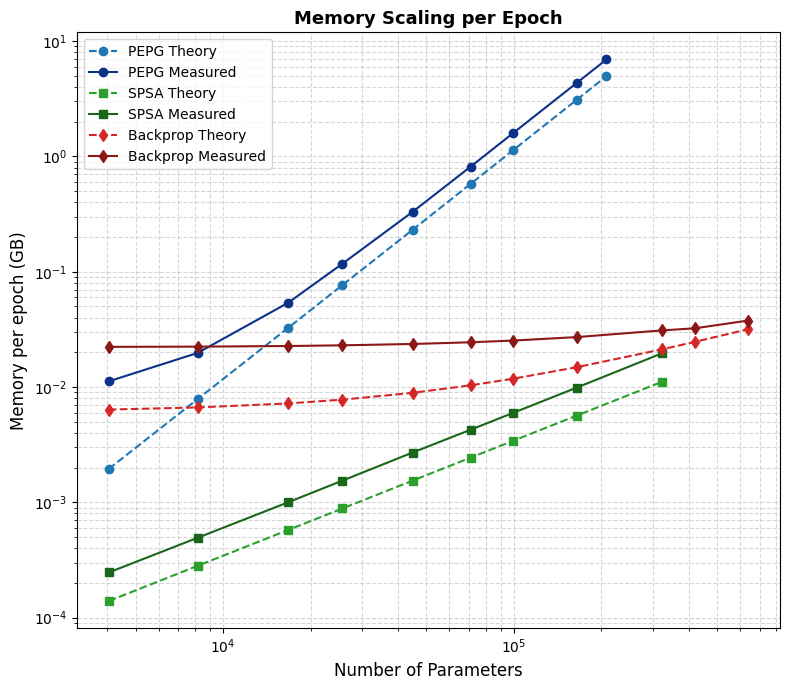

In [7]:
plt.figure(figsize=(8, 7))

# --- Color coding: same method = same hue ---
# PEPG: Blue tones
plt.loglog(N_params_PEPG, PEPG_mem_load_perepoch_theory, marker='o', linestyle='--',
           color="#1f77b4", label="PEPG Theory")
plt.loglog(N_params_PEPG, PEPG_mem_load_perepoch_measured_cuda, marker='o', linestyle='-',
           color="#0b3288", label="PEPG Measured")

# SPSA: Green tones
plt.loglog(N_params_SPSA, SPSA_mem_load_perepoch_theory, marker='s', linestyle='--',
           color="#2ca02c", label="SPSA Theory")
plt.loglog(N_params_SPSA, SPSA_mem_load_perepoch_measured_cuda, marker='s', linestyle='-',
           color="#1a661a", label="SPSA Measured")

# Backprop: Red tones
plt.loglog(N_params_BP, BP_mem_load_perepoch_theory, marker='d', linestyle='--',
           color="#d62728", label="Backprop Theory")
plt.loglog(N_params_BP, BP_mem_load_perepoch_measured_cuda, marker='d', linestyle='-',
           color="#8b1717", label="Backprop Measured")

plt.xlabel("Number of Parameters", fontsize=12)
plt.ylabel("Memory per epoch (GB)", fontsize=12)
plt.title("Memory Scaling per Epoch", fontsize=13, weight="bold")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

'p'

In [ ]:
#theoretical BP mem load

BP_mem_perepoch_1 = np.array([0.053, 0.1, 0.199, 0.302, 0.522, 0.822, 1.152, 1.896, 3.728, 4.816, 7.335])/1000 #peak total theory batch = 1
BP_mem_perepoch_5 = np.array([0.078, 0.126, 0.227, 0.332, 0.555, 0.861, 1.194, 1.948, 3.799, 4.895, 7.433])/1000
BP_mem_perepoch_10 = np.array([0.11, 0.159, 0.262, 0.369, 0.597, 0.908, 1.248, 2.013, 3.886, 4.995, 7.555])/1000 #peak total theory batch = 1
BP_mem_perepoch_20 = np.array([0.173, 0.225, 0.332, 0.444, 0.681, 1.004, 1.355, 2.142, 4.062, 5.193, 7.799])/1000 
BP_mem_perepoch_50 = np.array([0.363, 0.421, 0.542, 0.668, 0.933, 1.289, 1.675, 2.531, 4.588, 5.788, 8.531])/1000 
BP_mem_perepoch_100 = np.array([0.679, 0.749, 0.893, 1.041, 1.352, 1.766, 2.208, 3.179, 5.465, 6.779, 9.751])/1000
BP_mem_perepoch_200 = np.array([1.311, 1.404, 1.594, 1.788, 2.19, 2.719, 3.276, 4.476, 7.219, 8.762, 12.192])/1000 

BP_mem_perepoch_500 = np.array([3.209, 3.37, 3.697, 4.029, 4.706, 5.577, 6.478, 8.364, 12.481, 14.711, 19.514])/1000 
BP_mem_perepoch_1000 = np.array([6.371, 6.647, 7.203, 7.764, 8.898, 10.342, 11.815, 14.846, 21.251, 24.625, 31.717])/1000
BP_mem_perepoch_2000 = np.array([12.696, 13.201, 14.215, 15.233, 17.283, 19.871, 22.488, 27.808, 38.791, 44.454, 56.123])/1000

BP_mem_perepoch_5000 = np.array([31.67, 32.862, 35.249, 37.64, 42.437, 48.458, 54.509, 66.695, 91.411, 103.94, 129.343])/1000 
BP_mem_perepoch_10000 = np.array([63.294, 65.63, 70.306, 74.986, 84.36, 96.104, 107.876, 131.507, 179.111, 203.084, 251.375])/1000 


#  y-data arrays in a list (in the same order as plot )
BP_arrays = [
    BP_mem_perepoch_1,
    BP_mem_perepoch_5,
    BP_mem_perepoch_10,
    BP_mem_perepoch_20,
    BP_mem_perepoch_50,
    BP_mem_perepoch_100,
    BP_mem_perepoch_200,
    BP_mem_perepoch_500,
    BP_mem_perepoch_1000,
    BP_mem_perepoch_2000,
    BP_mem_perepoch_5000,
    BP_mem_perepoch_10000,
]

# The labels for the legend
labels = ["1", "5", "10", "20", "50", "100","200", "500", "1000","2000","5000","10000"]

# Build a colormap proportional to number of curves
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(BP_arrays)))

a_BP_batchsweep = []
b_BP_batchsweep = []
plt.figure()
for arr, label, color in zip(BP_arrays, labels, colors):
    plt.loglog(N_dim_vec_BP, arr, '--.', color=color, label=label)
    a_BP, b_BP = np.polyfit(np.log10(N_dim_vec_BP[-5:]), np.log10(arr[-5:]), 1)  # linear fit
    a_BP_batchsweep.append(a_BP)
    b_BP_batchsweep.append(b_BP)
    

# Legend depending on number
plt.legend(title="Batch size", fontsize=10)

plt.xlabel("# params")
plt.ylabel("Memory per epoch [GB]")
plt.title("BP Memory Scaling")
plt.grid(True, which="both", ls="--", alpha=0.4)

plt.show()


In [ ]:
#with measured load from CUDA torch instead of theory

BP_mem_perepoch_1 = np.array([18.19, 18.269, 18.443, 18.622, 19.001, 19.521, 20.097, 21.395, 24.587, 26.489, 31.049])/1000 
BP_mem_perepoch_5 = np.array([18.202, 18.281, 18.456, 18.635, 19.014, 19.533, 20.109, 21.407, 24.6, 26.502, 31.061])/1000
BP_mem_perepoch_10 = np.array([18.218, 18.297, 18.471, 18.651, 19.03, 19.549, 20.125, 21.423, 24.615, 26.518, 31.077])/1000 
BP_mem_perepoch_20 = np.array([18.249, 18.329, 18.503, 18.682, 19.061, 19.58, 20.156, 21.454, 24.647, 26.549, 31.108])/1000 
BP_mem_perepoch_50 = np.array([18.343, 18.423, 18.597, 18.776, 19.155, 19.675, 20.251, 21.549, 24.741, 26.643, 31.202])/1000 
BP_mem_perepoch_100 = np.array([18.501, 18.58, 18.754, 18.933, 19.312, 19.832, 20.408, 21.706, 24.898, 26.8, 31.359])/1000
BP_mem_perepoch_200 = np.array([18.815, 18.894, 19.068, 19.248, 19.626, 20.146, 20.722, 22.02, 25.212, 27.114, 31.674])/1000 

BP_mem_perepoch_500 = np.array([19.812, 20.686, 20.076, 21.079, 20.711, 22.068, 21.87, 23.945, 26.156, 28.853, 32.762])/1000 
BP_mem_perepoch_1000 = np.array([22.27, 22.378, 22.643, 22.951, 23.578, 24.39, 25.239, 27.018, 30.939, 33.817, 38.973])/1000
BP_mem_perepoch_2000 = np.array([24.798, 24.966, 25.391, 25.898, 26.927, 28.238, 29.586, 32.545, 38.466, 44.307, 52.754])/1000

BP_mem_perepoch_5000 = np.array([24.798, 24.966, 25.391, 25.898, 26.927, 28.238, 29.586, 32.545, 38.466, 44.307, 52.754])/1000 
BP_mem_perepoch_10000 = np.array([51.487, 52.135, 53.84, 56.279, 60.176, 66.421, 71.805, 81.615, 105.478, 129.487, 150.402])/1000 
BP_mem_perepoch_100000 = np.array([351.973, 358.021, 373.674, 396.697, 438.867, 484.323, 534.669, 639.537, 840.686, 938.513, 1141.897])/1000 
BP_mem_perepoch_1000000 = np.array([7681.618, 7741.665, 7901.772, 8101.879, 8502.107, 9002.421, 9504.99, 10503.547, 12507.174, 13506.61, 15511.27])/1000 

#  y-data arrays in a list (in the same order as plot )
BP_arrays = [
    BP_mem_perepoch_1,
    BP_mem_perepoch_5,
    BP_mem_perepoch_10,
    BP_mem_perepoch_20,
    BP_mem_perepoch_50,
    BP_mem_perepoch_100,
    BP_mem_perepoch_200,
    BP_mem_perepoch_500,
    BP_mem_perepoch_1000,
    BP_mem_perepoch_2000,
    BP_mem_perepoch_5000,
    BP_mem_perepoch_10000,
    BP_mem_perepoch_100000,
    BP_mem_perepoch_1000000
]

# The labels for the legend
labels = ["1", "5", "10", "20", "50", "100","200", "500", "1000","2000","5000","10000","100000","1000000"]

# Build a colormap proportional to number of curves
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(BP_arrays)))

a_BP_batchsweep = []
b_BP_batchsweep = []
plt.figure()
for arr, label, color in zip(BP_arrays, labels, colors):
    plt.loglog(N_dim_vec_BP, arr, '--.', color=color, label=label)
    a_BP, b_BP = np.polyfit(np.log10(N_dim_vec_BP[-5:]), np.log10(arr[-5:]), 1)  # linear fit
    a_BP_batchsweep.append(a_BP)
    b_BP_batchsweep.append(b_BP)
    

# Legend depending on number
plt.legend(title="Batch size", fontsize=10)

plt.xlabel("# params")
plt.ylabel("Memory per epoch [GB]")
plt.title("BP Memory Scaling")
plt.grid(True, which="both", ls="--", alpha=0.4)

plt.show()
